# py-destiny — Tutorial on Guo et al. 2010 fixture

## 1. What this package does

`pydestiny` is a port of [destiny](https://github.com/theislab/destiny) (Angerer et al. *Bioinformatics* 2016) — diffusion maps + diffusion pseudotime (DPT) for single-cell data.

**Citation**: Angerer, P. et al. *destiny: diffusion maps for large-scale single-cell data in R.* Bioinformatics 32, 1241 (2016)

## 2. Install + import

In [1]:
import sys
sys.path.insert(0, '/scratch/users/steorra/analysis/omicverse_traj_dev/py-destiny')
import pydestiny
import numpy as np, matplotlib.pyplot as plt
print(f'pydestiny {pydestiny.__version__}')

pydestiny 0.1.0


## 3. Load Guo data

(Pre-computed via R, saved as CSV sidecar.)

In [2]:
import pandas as pd
expr = pd.read_csv('/scratch/users/steorra/analysis/omicverse_traj_dev/py-destiny/data/fixture_guo_expression.csv', index_col=0).to_numpy(dtype=np.float64)
print(f'expression shape: {expr.shape}')

expression shape: (428, 48)


## 4. Public functions

### 4.1 DiffusionMap.fit(data, sigma, k, n_eigs, n_local, density_norm, distance)

eigenvalues:  [0.9865 0.9655 0.9103 0.9019 0.869 ]
eigvectors:   (428, 5)


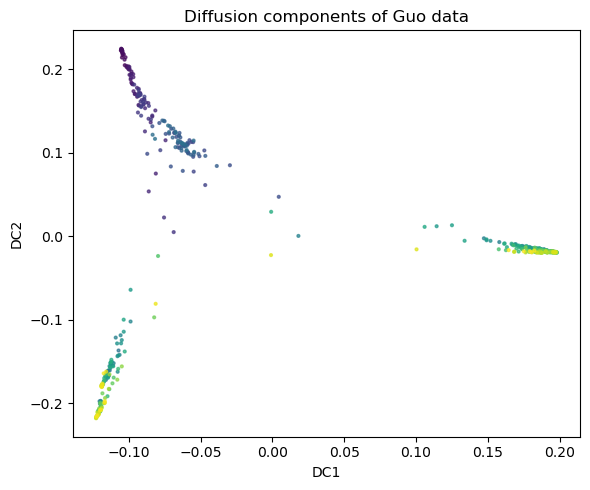

In [3]:
dm = pydestiny.DiffusionMap.fit(expr, sigma='local', n_eigs=5, n_local=5)
print(f'eigenvalues:  {dm.eigenvalues.round(4)}')
print(f'eigvectors:   {dm.eigenvectors.shape}')
# Visualise top 2 DCs
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(dm.eigenvectors[:, 0], dm.eigenvectors[:, 1], s=4, alpha=0.7, c=dm.eigenvalues[0]*np.arange(dm.eigenvectors.shape[0]), cmap='viridis')
ax.set_xlabel('DC1'); ax.set_ylabel('DC2'); ax.set_title('Diffusion components of Guo data')
plt.tight_layout(); plt.show()

### 4.2 DPT(dm, root)

DPT: min=0.000  max=1.000


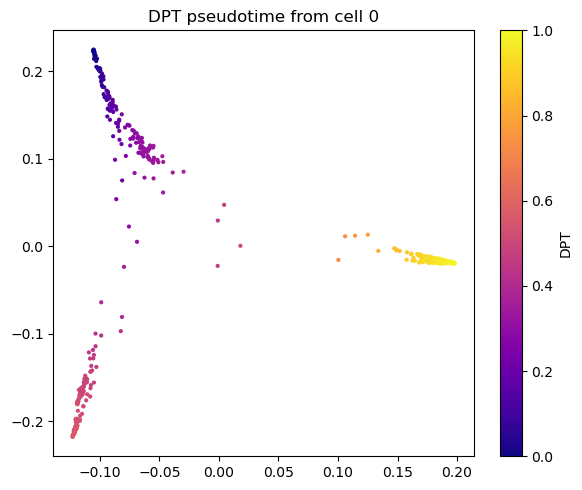

In [4]:
dpt = pydestiny.DPT(dm, root=0)
print(f'DPT: min={dpt.min():.3f}  max={dpt.max():.3f}')
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(dm.eigenvectors[:, 0], dm.eigenvectors[:, 1], c=dpt, cmap='plasma', s=4)
plt.colorbar(sc, label='DPT')
ax.set_title('DPT pseudotime from cell 0')
plt.tight_layout(); plt.show()

### 4.3 Sigmas + find_dm_k

In [5]:
k = pydestiny.find_dm_k(expr.shape[0])
print(f'default k for n={expr.shape[0]}: {k}')
sigmas = dm.sigmas
print(f'sigmas: shape {sigmas.sigmas.shape}, range [{sigmas.sigmas.min():.2f}, {sigmas.sigmas.max():.2f}]')

default k for n=428: 26
sigmas: shape (428,), range [8.06, 17.85]


## 5. Common pitfalls / FAQ
- **Local vs global sigma**: `sigma="local"` (default) chooses bandwidth per-cell from nearest-neighbour distances. Use `sigma="global"` for a single scale.
- **`density_norm=True`**: Markov-chain normalisation; essential for single-cell data with non-uniform sampling density.
- **DPT root cell**: choose a clearly-early cell. If unknown, use the cell at the extremum of DC1.

## 6. Next
- [`README.md`](../README.md), [`compare_R_vs_Python.ipynb`](compare_R_vs_Python.ipynb), [`function_by_function_R_parity.ipynb`](function_by_function_R_parity.ipynb)